<a href="https://colab.research.google.com/github/giveyourselfaTRY/phototaxis-pomdp-crn/blob/main/03_Benchmarking_and_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 Benchmarking and Plots

This notebook reuses the processed data and checkpoint exported by
`02_Data_Driven_IRL.ipynb` and reproduces the benchmark section from the
original `ML part biomodel phototaxis POMDP.ipynb` as faithfully as possible.

Main outputs:
- learned-policy trajectories
- modified Gillespie benchmark
- standard Gillespie benchmark
- tumble-ratio comparison
- alignment-distribution comparison
- tau-calibrated policy rollouts

In [1]:
from pathlib import Path
import sys, subprocess, os

REPO_NAME = "phototaxis-pomdp-crn"
REPO_URL = "https://github.com/giveyourselfaTRY/phototaxis-pomdp-crn.git"

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    ROOT = Path(f"/content/{REPO_NAME}")
    if not ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    os.chdir(ROOT)
    subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)
else:
    ROOT = Path.cwd().resolve()
    if ROOT.name != REPO_NAME and (ROOT / REPO_NAME).exists():
        ROOT = ROOT / REPO_NAME

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROC_DIR = DATA_DIR / "processed"
CKPT_DIR = ROOT / "checkpoints"
OUT_DIR = ROOT / "outputs"
FIG_DIR = OUT_DIR / "figures"
TRAJ_DIR = OUT_DIR / "trajectories"
TAB_DIR = OUT_DIR / "tables"

for d in [RAW_DIR, PROC_DIR, CKPT_DIR, FIG_DIR, TRAJ_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("PROC_DIR:", PROC_DIR)
print("CKPT_DIR:", CKPT_DIR)
print("FIG_DIR:", FIG_DIR)
print("TRAJ_DIR:", TRAJ_DIR)
print("TAB_DIR:", TAB_DIR)

ROOT: /content/phototaxis-pomdp-crn
PROC_DIR: /content/phototaxis-pomdp-crn/data/processed
CKPT_DIR: /content/phototaxis-pomdp-crn/checkpoints
FIG_DIR: /content/phototaxis-pomdp-crn/outputs/figures
TRAJ_DIR: /content/phototaxis-pomdp-crn/outputs/trajectories
TAB_DIR: /content/phototaxis-pomdp-crn/outputs/tables


In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from scipy.stats import ks_2samp, wasserstein_distance, entropy

clean_csv = PROC_DIR / "clean_movie_52_with_speed.csv"
action_csv = PROC_DIR / "clean_movie_52_with_speed_and_action.csv"
ckpt_path = CKPT_DIR / "experiment_checkpoint.pkl"

df_clean = pd.read_csv(clean_csv)
df_action = pd.read_csv(action_csv)

with open(ckpt_path, "rb") as f:
    ckpt = pickle.load(f)

TT_learn = torch.tensor(ckpt["TT_learn"], dtype=torch.float32)
ZZ_learn = torch.tensor(ckpt["ZZ_learn"], dtype=torch.float32)
r_star = np.asarray(ckpt["r_star"], dtype=float)

kin_sim = ckpt["kin_sim"]
geom = ckpt["geom"]
src = ckpt["src"]
sensor = ckpt["sensor"]
light_xy = np.asarray(ckpt["light_xy"], dtype=float)

n = int(ckpt["n"])
m = int(ckpt["m"])
dt_policy = float(ckpt["dt_policy"])
stats = ckpt["stats"]
train_cells = list(map(int, ckpt.get("train_cells", [])))
test_cells = list(map(int, ckpt.get("test_cells", [])))
df_test_index = list(map(int, ckpt.get("df_test_index", [])))



print("Loaded checkpoint:", ckpt_path)
print("Checkpoint keys:", list(ckpt.keys()))

print("n, m =", n, m)
print("dt_policy =", dt_policy)
print("light_xy =", light_xy)
print("train_cells =", train_cells)
print("test_cells =", test_cells)
print("df_test_index length =", len(df_test_index))

p_real_original = float(ckpt["p_real_original"])
real_alignment_values_ckpt = np.asarray(ckpt["real_alignment_values"], dtype=float)
df_test_index = list(map(int, ckpt.get("df_test_index", [])))

Loaded checkpoint: /content/phototaxis-pomdp-crn/checkpoints/experiment_checkpoint.pkl
Checkpoint keys: ['TT_learn', 'ZZ_learn', 'r_star', 'kin_sim', 'geom', 'src', 'sensor', 'light_xy', 'n', 'm', 'dt_policy', 'stats', 'train_cells', 'test_cells', 'df_test_index', 'p_real_original', 'real_alignment_values', 'meta']
n, m = 5 2
dt_policy = 0.1299999999999954
light_xy = [252.10614314 335.41309536]
train_cells = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 18, 19, 20, 21, 22, 24, 25, 26, 28, 29]
test_cells = [27, 15, 23, 17]
df_test_index length = 2773


In [3]:
import math
import numpy as np

# ---------- tool ----------
def _normalize(v, eps=1e-12):
    v = np.asarray(v, float); n = np.linalg.norm(v) + eps
    return v / n

def _R2(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[c,-s],[s,c]], float)

# ---------- geometry of the agent ----------
class CircularAgent:
    def __init__(self, center, radius, heading_angle_deg, beta_deg=30.0, alpha_deg=20.0, fov_deg=60.0):
        self.x   = np.array(center, float)
        self.R   = float(radius)
        self.d   = _R2(np.deg2rad(heading_angle_deg)) @ np.array([1.0,0.0])
        self.d   = _normalize(self.d)
        self.beta= np.deg2rad(beta_deg)
        self.alpha=np.deg2rad(alpha_deg)
        self.fov = np.deg2rad(fov_deg)
        # eyespot
        self.xL  = self.x + self.R * (_R2(+self.beta) @ self.d)
        self.xR  = self.x + self.R * (_R2(-self.beta) @ self.d)
        # optical axis
        self.uL  = _normalize(_R2(+self.alpha) @ self.d)
        self.uR  = _normalize(_R2(-self.alpha) @ self.d)
        # normal
        self.nL  = _normalize(self.xL - self.x)
        self.nR  = _normalize(self.xR - self.x)

# ---------- visibility gates ----------
def _occ_gate(n_eye, dir_to_src):
    # occlusion gate
    return 1.0 if float(np.dot(n_eye, dir_to_src)) >= 0.0 else 0.0

def _fov_gate(u_eye, dir_to_src, fov_half_angle_rad):
    # fov gate
    return 1.0 if float(np.dot(u_eye, dir_to_src)) >= np.cos(fov_half_angle_rad) else 0.0

# ---------- light diffusion ----------
def _gaussian_blob(I0, mu, sigma, at_point):
    r  = at_point - mu
    r2 = float(np.dot(r,r))
    return I0 * np.exp(-0.5 * r2 / (sigma**2))

def _invsq(r2, eps=1e-6):  # aerial
    return 1.0 / (r2 + eps)

def _logistic_distance(s, beta_d=0.5):  # under water
    return 1.0 / (1.0 + np.exp(beta_d * s))

def _per_eye_I(agent, mu, I0=1.0, sigma=1.0, use_invsq=False, use_logdist=True, beta_d=0.5):
    out = {}
    for side in ("L","R"):
        x_eye = getattr(agent, f"x{side}")
        u_eye = getattr(agent, f"u{side}")
        n_eye = getattr(agent, f"n{side}")
        dir_to_src = _normalize(mu - x_eye)
        rvec = x_eye - mu; r2 = float(np.dot(rvec,rvec)); s = np.sqrt(r2)
        occ = _occ_gate(n_eye, dir_to_src)
        fov = _fov_gate(u_eye, dir_to_src, agent.fov)
        g   = occ * fov                         # 早期门控（方案A）
        base= _gaussian_blob(I0, mu, sigma, x_eye)
        if use_invsq:      base *= _invsq(r2)
        if use_logdist:    base *= _logistic_distance(s, beta_d=beta_d)
        cos_inc = max(0.0, float(np.dot(u_eye, dir_to_src)))   # 入射余弦 [·]_+
        out[side] = dict(I = g * base * cos_inc,
                         occ=occ, fov=fov, cos_inc=cos_inc, s=s, r2=r2)
    return out

# ---------- saturation ----------
def _S_logistic(I, beta_s=3.0, I50=0.01):
    #saturation: S(I)=1/(1+exp(-β_s (I-I50)))
    return 1.0 / (1.0 + np.exp(-beta_s * (I - I50)))

def _bin_strong_weak(y, thr=0.5):   # m=2 的二档
    return 1 if y >= thr else 0

# ---------- observation ----------
def observation_biophysical(x, xl, v, n, m,
              geom,src,sensor):
    """
    return (o_L, o_R) ∈ {0,...,m-1}^2；
    """
    # heading
    heading_angle_deg = float(np.rad2deg(np.arctan2(v[1], v[0])))
    agent = CircularAgent(center=x, radius=geom["R"], heading_angle_deg=heading_angle_deg,
                          beta_deg=geom["beta_deg"], alpha_deg=geom["alpha_deg"], fov_deg=geom["fov_deg"])
    per_eye = _per_eye_I(agent, np.asarray(src["mu"], float),
                         I0=src["I0"], sigma=src["sigma"],
                         use_invsq=src["use_invsq"], use_logdist=src["use_logdist"], beta_d=src["beta_d"])
    IL = per_eye["L"]["I"]; IR = per_eye["R"]["I"]
    yL = _S_logistic(IL, beta_s=sensor["beta_s"], I50=sensor["I50"])
    yR = _S_logistic(IR, beta_s=sensor["beta_s"], I50=sensor["I50"])
    oL = _bin_strong_weak(yL, thr=sensor["thr"])
    oR = _bin_strong_weak(yR, thr=sensor["thr"])
    return np.array([oL, oR], dtype=int)

# ---------- transition + emission matrix ----------
def init_transition_biophysical(n, m, a,
                geom, src, sensor,
                ref_x=np.array([0.0,0.0]), ref_xl=None, eps_col=0.1):

    import torch
    # same tranisiton matrix as before
    T= torch.zeros([a,n,n])
    Z=torch.zeros([m,m,n])



    T[0]= torch.eye(n)
    T= T+0.1*torch.ones([a,n,n])

    # for every hidden state (prototype) build a reference velocity
    for h in range(n):
        theta = 2*np.pi*h/n
        v_ref = np.array([np.cos(theta), np.sin(theta)], float)
        if ref_xl is None:
            ref_xl = np.asarray(src["mu"], float)  # light source
        o = observation_biophysical(ref_x, ref_xl, v_ref, n, m, geom, src, sensor)  # (oL,oR)
        # weighted and normalization as before for the emission matrix
        Z[o[0], o[1], h] = 10.0
    Z = Z + eps_col * torch.ones_like(Z)
    # column normalization
    Z = Z.reshape(m*m, n)
    Z = Z / torch.clamp(Z.sum(dim=0, keepdim=True), min=1e-12)
    Z = Z.reshape(m, m, n)


    def normalize_t(TT):
        sh = TT.shape
        out = torch.einsum('...ij,k->...kj', TT, torch.ones(sh[-2], dtype=TT.dtype, device=TT.device))
        return TT / out
    return normalize_t(T), Z


def mutual_information(b: torch.Tensor, ZZ: torch.Tensor) -> torch.Tensor:
    """
    b: (n,) torch tensor (belief / prior)
    ZZ: either (m,m,n) or (m*m,n) emission matrix (columns sum to 1)
    returns: scalar torch tensor
    """
    # Match dtype/device to ZZ
    b = b.to(dtype=ZZ.dtype, device=ZZ.device)

    # Flatten to (m*m, n)
    if ZZ.dim() == 3:
        m1, m2, n = ZZ.shape
        Z = ZZ.reshape(m1*m2, n)
    else:
        Z = ZZ
        n = Z.shape[1]

    # Column-normalize (safety)
    Z = Z / torch.clamp(Z.sum(dim=0, keepdim=True), min=1e-12)

    # Marginal: o = Z b
    o = Z @ b  # (m*m,)


    # term = sum_h b_h sum_v Z[v,h] log Z[v,h] - sum_v o_v log o_v
    logZ = torch.log(torch.clamp(Z, min=1e-12))
    col_term = (Z * logZ).sum(dim=0)        # (n,)
    term2 = (b * col_term).sum() - (o * torch.log(torch.clamp(o, min=1e-12))).sum()
    return term2



def update(b,o,a,TT,ZZ):
    #update belief
    v=np.zeros(len(b))
    o1=o[0]
    o2=o[1]
    for i in range(len(b)):
        v[i]=ZZ[o1,o2,i]*b[i]
    return v/v.sum()

class Env:
  def __init__(self,geom,src,sensor,TT,ZZ):
    self.geom=geom
    self.src=src
    self.sensor=sensor
    self.TT=TT
    self.ZZ=ZZ


## Rebuild benchmark context from checkpoint

In [4]:
env_new = Env(geom, src, sensor, TT_learn, ZZ_learn)
mu = np.asarray(env_new.src["mu"], float)
N = 30

# ---- original-ML tumble benchmark target ----
# NOTE:
# This is the original ML semantics: tau calibration uses p_real from df_grid,
# which is now frozen into the checkpoint as p_real_original.
p_real = p_real_original

# ---- held-out alignment target ----
if len(test_cells) > 0 and "cell_id" in df_clean.columns:
    df_real_test = df_clean[df_clean["cell_id"].isin(test_cells)].copy()
else:
    df_real_test = df_clean.copy()

data_cos = np.asarray(real_alignment_values_ckpt, dtype=float)

print("env_new rebuilt.")
print("p_real =", p_real)
print("df_real_test rows =", len(df_real_test))
print("real_alignment_values length =", len(data_cos))

env_new rebuilt.
p_real = 0.02727474123217852
df_real_test rows = 2346
real_alignment_values length = 2773


In [5]:
import numpy as np, torch, matplotlib.pyplot as plt

# --- Build the soft policy π_r(a|b) from reward r^* and (T, Z)
def policy_from_reward(r_star, TT, ZZ, tau=1.0, curiosity=0.0):
    r_t = torch.tensor(r_star, dtype=torch.float64)
    def f(b_np):
        b = torch.tensor(b_np, dtype=torch.float32)
        Qa = []
        for a in range(TT.shape[0]):
            Tb = TT[a].to(dtype=torch.float32) @ b
            term1 = (r_t.to(dtype=torch.float32) * Tb).sum()
            if curiosity != 0.0:
                term2 = mutual_information(Tb, ZZ.to(dtype=torch.float32))
            else:
                term2 = torch.tensor(0.0, dtype=torch.float32)
            Qa.append((term1 + curiosity * term2) / tau)
        P = torch.softmax(torch.stack(Qa), dim=0)
        return float(P[1])   # P(tumble)
    return f

def pomdp_update(b, a, o, TT, ZZ):
    Tb = b
    like = ZZ[o[0], o[1], :].clamp_min(1e-12)
    post = like * Tb
    return post / post.sum().clamp_min(1e-12)

def kinematics_step(x, v, a, dt, c_run, c_tum, rng, turn_noise_std=0.05):
    if a == 0:  # run
        u = v / (np.linalg.norm(v) + 1e-12)
        ang = rng.normal(0.0, turn_noise_std)
        R = np.array([[np.cos(ang), -np.sin(ang)],
                      [np.sin(ang),  np.cos(ang)]])
        u = R @ u
        v_new = c_run * u
    else:       # tumble
        phi = rng.uniform(0, 2*np.pi)
        u = np.array([np.cos(phi), np.sin(phi)])
        v_new = c_tum * u
    x_new = x + dt * v_new
    return x_new, v_new

def simulate_pomdp(env, policy_fn, kin, steps=800, dt=0.125, seed=0, x0=None, random=False):
    rng = np.random.default_rng(seed)
    n = env.TT.shape[1]
    m = env.ZZ.shape[0]

    if random:
        x = rng.uniform(-2, 2, size=2).astype(float) if x0 is None else np.array(x0, float)
    else:
        x = np.array([0.0, 0.0], float) if x0 is None else np.array(x0, float)

    v = _normalize(env.src['mu'] - x)

    b = np.ones(n, float) / n
    traj = [x.copy()]
    acts = []
    vlist = [v.copy()]
    bels = [b.copy()]

    o = observation_biophysical(x, env.src["mu"], v, n, m, env.geom, env.src, env.sensor)
    a = 0

    for _ in range(steps):
        b_torch = torch.tensor(b, dtype=torch.float32)
        b = pomdp_update(b_torch, a, o,
                         env.TT.to(dtype=torch.float32),
                         env.ZZ.to(dtype=torch.float32)).cpu().numpy()

        p_tum = policy_fn(b)
        a = 1 if rng.random() < p_tum else 0

        x, v = kinematics_step(x, v, a, dt, kin["c_run"], kin["c_tum"], rng)
        o = observation_biophysical(x, env.src["mu"], v, n, m, env.geom, env.src, env.sensor)

        traj.append(x.copy())
        acts.append(a)
        vlist.append(v.copy())
        bels.append(b.copy())

    return np.array(traj), np.array(acts), np.array(bels), np.array(vlist[1:])

def plot_trajectory(traj, actions=None, src_mu=None, title="Simulated trajectory", savepath=None):
    plt.figure(figsize=(5.2, 5.2))
    if actions is None:
        plt.plot(traj[:, 0], traj[:, 1], '-', lw=1.5, alpha=0.9)
    else:
        colors = np.where(actions == 1, "orange", "steelblue")
        plt.scatter(traj[1:, 0], traj[1:, 1], c=colors, s=8)
        plt.plot(traj[:, 0], traj[:, 1], alpha=0.4, color="#666666")
        handles = [
            plt.Line2D([0], [0], marker='o', color='w', label='run',
                       markerfacecolor='steelblue', markersize=6),
            plt.Line2D([0], [0], marker='o', color='w', label='tumble',
                       markerfacecolor='orange', markersize=6)
        ]
        plt.legend(handles=handles, loc="best")
    plt.scatter(traj[0, 0], traj[0, 1], c='g', s=50, label="start")
    plt.scatter(traj[-1, 0], traj[-1, 1], c='black', s=50, label="end")
    if src_mu is not None:
        plt.scatter(src_mu[0], src_mu[1], marker='*', s=130, c='red', label='light')
    plt.axis('equal')
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(alpha=0.2)
    plt.legend(loc="best")
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=160)
    plt.show()

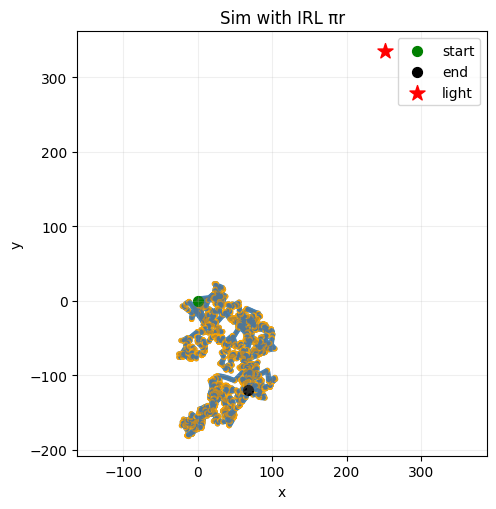

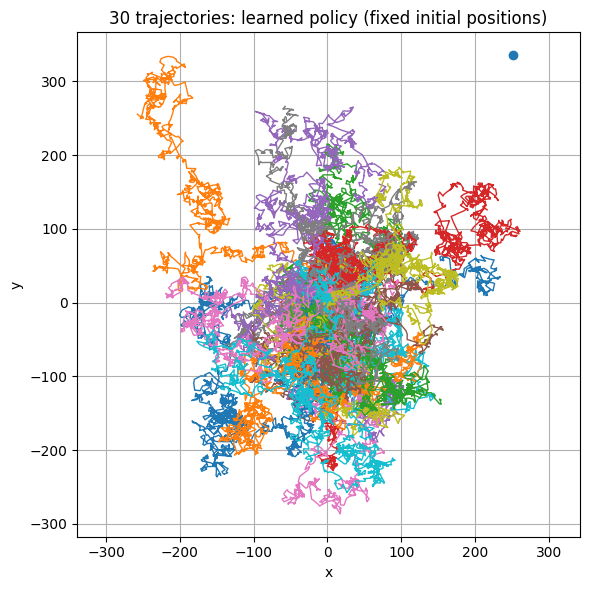

In [6]:
pi_r = policy_from_reward(r_star, env_new.TT, env_new.ZZ, tau=1.0, curiosity=0.0)

traj, acts, bels, vlist = simulate_pomdp(
    env_new, pi_r, kin_sim, steps=4000, dt=dt_policy, seed=0
)
plot_trajectory(
    traj, acts, src_mu=env_new.src["mu"],
    title="Sim with IRL πr",
    savepath=FIG_DIR / "fig_one_trajectory_policy.png"
)

N = 30
policy_trajs = []
for i in range(N):
    traj, acts, bels, vlist = simulate_pomdp(
        env_new, pi_r, kin_sim, random=False, steps=4000, dt=dt_policy, seed=1000 + i
    )
    run_id = np.full(len(traj), i, int)
    step_id = np.arange(len(traj))
    acts = [0] + acts.tolist()

    df_one = pd.DataFrame(dict(
        run_id=run_id,
        step=step_id,
        x=traj[:, 0],
        y=traj[:, 1],
        action=acts,
        dt=dt_policy
    ))
    policy_trajs.append(df_one)

df_policy = pd.concat(policy_trajs, ignore_index=True)
df_policy.to_csv(TRAJ_DIR / "trajs_policy.csv", index=False)

plt.figure(figsize=(6, 6))
for i in range(N):
    dfi = df_policy[df_policy.run_id == i]
    plt.plot(dfi.x.values, dfi.y.values, linewidth=1.0)
plt.scatter([light_xy[0]], [light_xy[1]])
plt.title("30 trajectories: learned policy (fixed initial positions)")
plt.xlabel("x"); plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_trajectories_policy.png", dpi=160)
plt.show()

# sum_pol = df_policy.groupby('run_id').apply(
#     lambda g: pd.Series(dict(
#         method='policy',
#         step_ratio=float((g['action'] == 1).mean()),
#         time_ratio=float((g['action'] * g['dt']).sum() / g['dt'].sum())
#     ))
# ).reset_index()

# display(sum_pol.head())

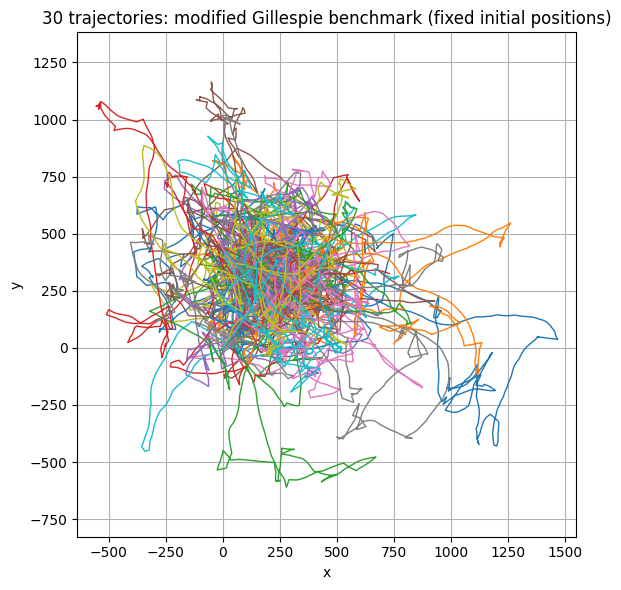

/tmp/ipykernel_10743/1725004965.py:106: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sum_gil_m = df_gill_m.groupby('run_id').apply(
/tmp/ipykernel_10743/1725004965.py:114: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sum_pol = df_policy.groupby('run_id').apply(


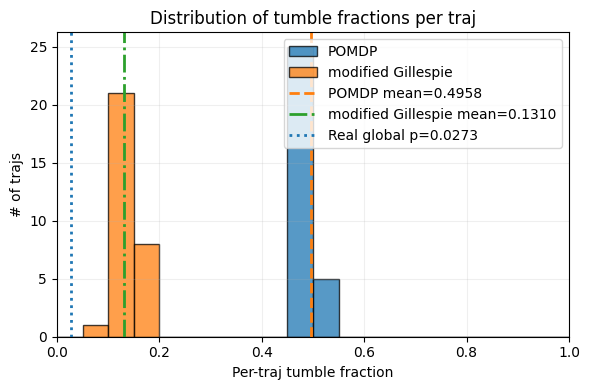

In [9]:
def _alignment(x, v, mu):
    u = _normalize(v)
    s = _normalize(np.asarray(mu, float) - np.asarray(x, float))
    return float(np.clip(np.dot(u, s), -1.0, 1.0))

def simulate_gillespie_modified(
    env, kin, x0, total_time=100.0, dt_grid=0.125, seed=0,
    rt_min_max=(0.06, 0.60), gamma=1.0, lambda_tum_to_run=1.2, turn_noise_std=0.05
):
    rng = np.random.default_rng(seed)

    x = x0
    mu = env.src["mu"]
    v = _normalize(env.src["mu"] - x)

    c_run = float(kin["c_run"])
    c_tum = float(kin["c_tum"])

    state = 0  # run
    t = 0.0
    t_next_out = dt_grid

    def _lambda_rt(x, v, mu):
        align = (_alignment(x, v, mu) + 1.0) * 0.5
        lam_min, lam_max = rt_min_max
        return lam_min + (lam_max - lam_min) * ((1.0 - align) ** gamma)

    lam = _lambda_rt(x, v, mu)
    t_next_event = t + rng.exponential(1.0 / max(lam, 1e-8))
    tumble_u = None

    rows = []

    while t < total_time:
        t_end = min(t_next_out, t_next_event, total_time)
        h = t_end - t
        if h > 0:
            if state == 0:
                u = _normalize(v)
                ang = rng.normal(0.0, turn_noise_std)
                c, s = np.cos(ang), np.sin(ang)
                R = np.array([[c, -s], [s, c]])
                u = R @ u
                v = c_run * u
                x = x + h * v
            else:
                if tumble_u is None:
                    phi = rng.uniform(0, 2*np.pi)
                    tumble_u = np.array([np.cos(phi), np.sin(phi)])
                v = c_tum * tumble_u
                x = x + h * v

            t += h

            if abs(t - t_next_out) < 1e-12 or (t == total_time and t < t_next_out):
                rows.append(dict(
                    t=t, dt=h, x=x[0], y=x[1],
                    action=int(state),
                    align=_alignment(x, v, mu)
                ))
                t_next_out += dt_grid

        if abs(t - t_next_event) < 1e-12 or (
            t_next_event < t_next_out and t_next_event <= total_time and t == t_next_event
        ):
            if state == 0:
                state = 1
                tumble_u = None
                lam = lambda_tum_to_run
            else:
                state = 0
                lam = _lambda_rt(x, v, mu)
            t_next_event = t + rng.exponential(1.0 / max(lam, 1e-8))

    return pd.DataFrame(rows)

steps = 4000
dt_grid = dt_policy
total_time = steps * dt_grid

gill_trajs_m = []
for i in range(N):
    dfi_g_m = simulate_gillespie_modified(
        env_new, kin_sim, x0=np.array([0, 0], dtype=float),
        total_time=total_time, dt_grid=dt_grid, seed=1000 + i
    )
    dfi_g_m.insert(0, 'run_id', i)
    gill_trajs_m.append(dfi_g_m)

df_gill_m = pd.concat(gill_trajs_m, ignore_index=True)
df_gill_m.to_csv(TRAJ_DIR / "trajs_modified_gillespie.csv", index=False)

plt.figure(figsize=(6, 6))
for i in range(N):
    g_dfi_m = df_gill_m[df_gill_m.run_id == i]
    plt.plot(g_dfi_m.x.values, g_dfi_m.y.values, linewidth=1.0)
plt.scatter([light_xy[0]], [light_xy[1]])
plt.title("30 trajectories: modified Gillespie benchmark (fixed initial positions)")
plt.xlabel("x"); plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_trajectories_modified_gillespie.png", dpi=160)
plt.show()

sum_gil_m = df_gill_m.groupby('run_id').apply(
    lambda g: pd.Series(dict(
        method='modified gillespie',
        step_ratio=float((g['action'] == 1).mean()),
        time_ratio=float((g['action'] * g['dt']).sum() / g['dt'].sum())
    ))
).reset_index()

sum_pol = df_policy.groupby('run_id').apply(
    lambda g: pd.Series(dict(
        method='policy',
        step_ratio=float((g['action']==1).mean()),
        time_ratio=float((g['action']*g['dt']).sum()/g['dt'].sum())
    ))
).reset_index()

vals_p = sum_pol['time_ratio'].dropna().to_numpy()
vals_gm = sum_gil_m["time_ratio"].dropna().to_numpy()
bins = np.linspace(0, 1, 21)
p_sim = vals_p.mean()
p_gm = vals_gm.mean()

plt.figure(figsize=(6, 4))
plt.hist(vals_p, bins=bins, alpha=0.75, edgecolor="k", label="POMDP")
plt.hist(vals_gm, bins=bins, alpha=0.75, edgecolor="k", label="modified Gillespie")
plt.axvline(p_sim, color="C1", ls="--", lw=2, label=f"POMDP mean={p_sim:.4f}")
plt.axvline(p_gm, color="C2", ls="-.", lw=2, label=f"modified Gillespie mean={p_gm:.4f}")
plt.axvline(p_real, color="C0", ls=":", lw=2, label=f"Real global p={p_real:.4f}")
plt.xlabel("Per-traj tumble fraction")
plt.ylabel("# of trajs")
plt.title("Distribution of tumble fractions per traj")
plt.legend()
plt.xlim(0, 1)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_tumble_ratio_policy_vs_modified_gillespie.png", dpi=160)
plt.show()

## Alignment metrics and comparison against modified Gillespie

/tmp/ipykernel_10743/2448086154.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('run_id', as_index=False, group_keys=False).apply(_diff_vel)
/tmp/ipykernel_10743/2448086154.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('run_id', as_index=False, group_keys=False).apply(_diff_vel)


Using frozen real_alignment_values from checkpoint. n = 2773


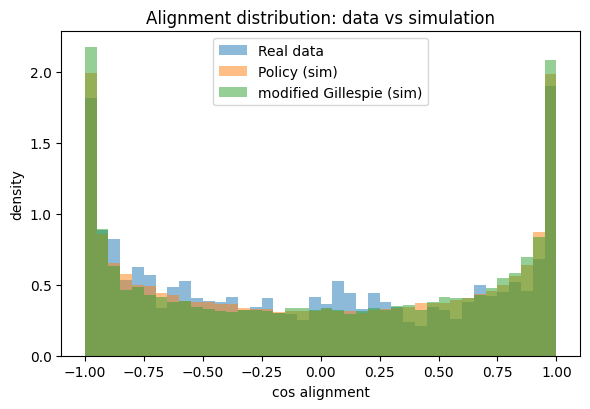

n_data              1.200000e+05
n_sim               1.199700e+05
KS_D                1.555868e-02
KS_p                4.807083e-13
W1                  1.865868e-02
JS                  7.446538e-04
hist_L1             6.359444e-02
E_cos_data         -3.364199e-03
E_cos_sim           1.117401e-02
P(cos>0.8)_data     2.029000e-01
P(cos>0.8)_sim      2.096357e-01
P(cos<-0.8)_data    2.038833e-01
P(cos<-0.8)_sim     2.082771e-01
dtype: float64

CIs (bootstrap 95%):
KS_D   in [0.013, 0.020]
W1     in [0.014, 0.024]
JS     in [0.001, 0.001]
hist_L1 in [0.059, 0.073]


,KS,KS_p,W1,JS,hist_L1
pair,,,,,
Policy vs Gillespie,0.0156,0.0000,0.0187,0.0007,0.0636
Real vs Gillespie,0.0650,0.0000,0.0638,0.0062,0.1894
Real vs Policy,0.0536,0.0000,0.0458,0.0048,0.1528



95% bootstrap CI:
- Real vs Policy: KS[0.038,0.074]  W1[0.026,0.072]  JS[0.0048,0.0088]  L1[0.148,0.208]
- Real vs Gillespie: KS[0.050,0.084]  W1[0.045,0.087]  JS[0.0058,0.0102]  L1[0.174,0.241]
- Policy vs Gillespie: KS[0.013,0.020]  W1[0.014,0.024]  JS[0.0007,0.0010]  L1[0.059,0.073]


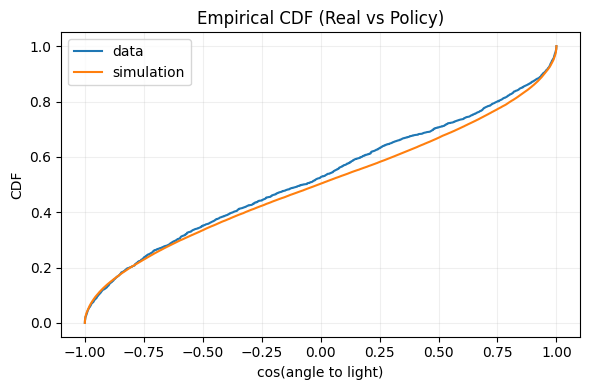

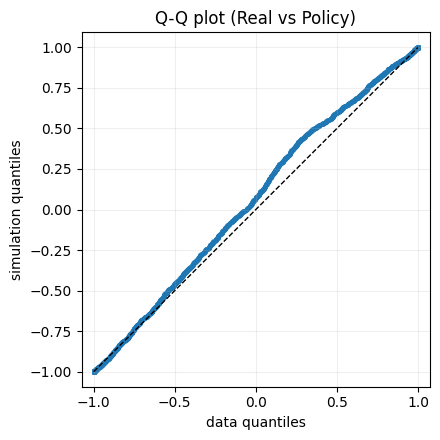

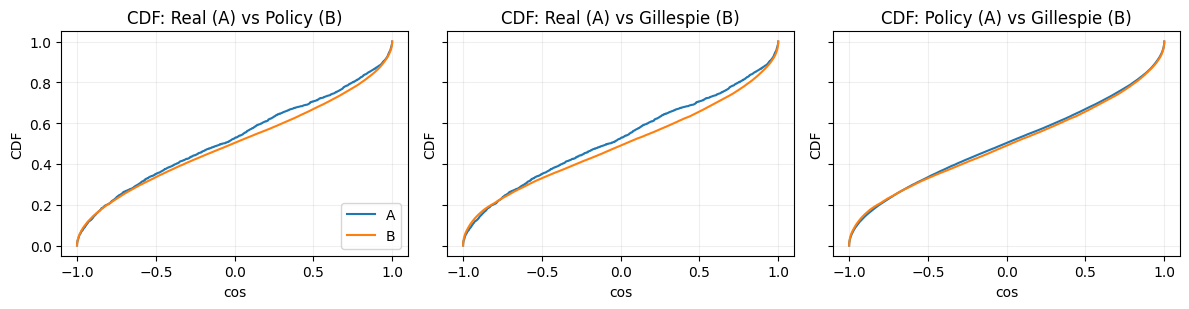

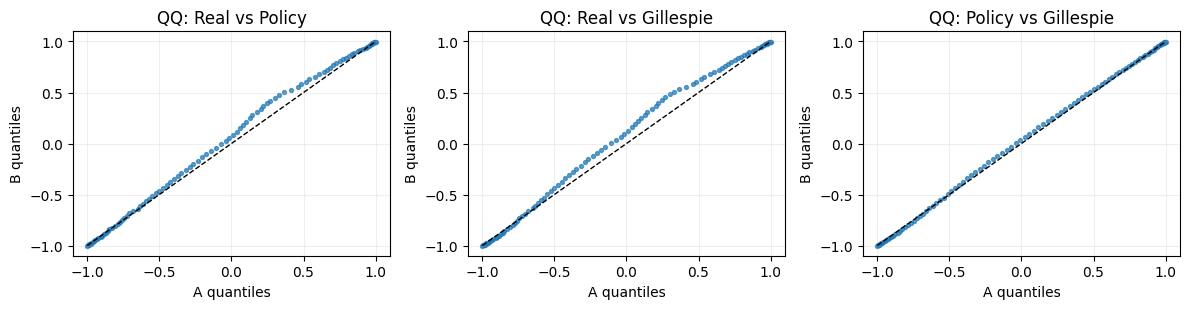

In [10]:
# ---------- Alignment (cosine) and histograms ----------
def alignment_cos_from_traj(traj, vlist, mu, eps=1e-9):
    u = vlist / (np.linalg.norm(vlist, axis=1, keepdims=True) + eps)
    d = (np.asarray(mu, float) - traj)
    d = d / (np.linalg.norm(d, axis=1, keepdims=True) + eps)
    cosv = np.sum(u * d, axis=1)
    return cosv

def js_divergence(x, y, bins=40, rng=(-1,1), eps=1e-12):
    px, _ = np.histogram(x, bins=bins, range=rng, density=True)
    py, _ = np.histogram(y, bins=bins, range=rng, density=True)
    px = px / (px.sum() + eps)
    py = py / (py.sum() + eps)
    m  = 0.5 * (px + py)
    return 0.5 * entropy(px + eps, m + eps) + 0.5 * entropy(py + eps, m + eps)

def hist_L1(x, y, bins=40, rng=(-1,1)):
    px, _ = np.histogram(x, bins=bins, range=rng, density=True)
    py, _ = np.histogram(y, bins=bins, range=rng, density=True)
    width = (rng[1] - rng[0]) / bins
    return np.abs(px - py).sum() * width

def tail_probs(z, thr=0.8):
    z = z[np.isfinite(z)]
    return (np.mean(z > +thr), np.mean(z < -thr))

def summarize_alignment(sim_cos, data_cos, bins=40, rng=(-1,1)):
    sim = sim_cos[np.isfinite(sim_cos)]
    dat = data_cos[np.isfinite(data_cos)]
    ks = ks_2samp(dat, sim, alternative='two-sided', mode='auto')
    w1 = wasserstein_distance(dat, sim)
    js = js_divergence(dat, sim, bins=bins, rng=rng)
    l1 = hist_L1(dat, sim, bins=bins, rng=rng)
    p_plus_dat, p_minus_dat = tail_probs(dat, 0.8)
    p_plus_sim, p_minus_sim = tail_probs(sim, 0.8)
    return {
        "n_data": len(dat), "n_sim": len(sim),
        "KS_D": ks.statistic, "KS_p": ks.pvalue,
        "W1": w1, "JS": js, "hist_L1": l1,
        "E_cos_data": float(np.mean(dat)), "E_cos_sim": float(np.mean(sim)),
        "P(cos>0.8)_data": p_plus_dat, "P(cos>0.8)_sim": p_plus_sim,
        "P(cos<-0.8)_data": p_minus_dat, "P(cos<-0.8)_sim": p_minus_sim,
    }

def bootstrap_ci(fn, x, y, B=1000, alpha=0.05, random_state=0):
    rng = np.random.default_rng(random_state)
    vals = []
    n, m = len(x), len(y)
    for _ in range(B):
        xb = x[rng.integers(0, n, n)]
        yb = y[rng.integers(0, m, m)]
        vals.append(fn(xb, yb))
    lo = np.percentile(vals, 100 * alpha / 2)
    hi = np.percentile(vals, 100 * (1 - alpha / 2))
    return float(lo), float(hi)

def plot_cdf_compare(x, y, title="Empirical CDF (alignment)", savepath=None):
    xs = np.sort(x[np.isfinite(x)])
    ys = np.sort(y[np.isfinite(y)])
    Fx = np.arange(1, len(xs) + 1) / len(xs)
    Fy = np.arange(1, len(ys) + 1) / len(ys)
    plt.figure(figsize=(6, 4))
    plt.plot(xs, Fx, label="data")
    plt.plot(ys, Fy, label="simulation")
    plt.xlabel("cos(angle to light)")
    plt.ylabel("CDF")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=160)
    plt.show()

def plot_qq_compare(x, y, title="Q-Q plot (alignment)", savepath=None):
    xs = np.sort(x[np.isfinite(x)])
    ys = np.sort(y[np.isfinite(y)])
    k = min(len(xs), len(ys))
    xs = xs[np.linspace(0, len(xs) - 1, k).astype(int)]
    ys = ys[np.linspace(0, len(ys) - 1, k).astype(int)]
    plt.figure(figsize=(4.5, 4.5))
    plt.scatter(xs, ys, s=6, alpha=0.6)
    lim = [-1, 1]
    plt.plot(lim, lim, 'k--', lw=1)
    plt.xlabel("data quantiles")
    plt.ylabel("simulation quantiles")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.axis('equal')
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=160)
    plt.show()

def alignment_from_df(df, mu_xy, vx_col='vx', vy_col='vy'):
    mu = np.asarray(mu_xy, float)
    df = df.copy()

    if vx_col not in df.columns or vy_col not in df.columns:
        if 'run_id' not in df.columns:
            df['run_id'] = 0
        if 'dt' not in df.columns:
            raise ValueError("When vx/vy are absent, df must contain a dt column.")

        def _diff_vel(g):
            g = g.sort_values('t' if 't' in g.columns else 'step')
            x = g['x'].to_numpy()
            y = g['y'].to_numpy()
            dt = g['dt'].to_numpy()
            vx = np.empty_like(x)
            vy = np.empty_like(y)
            vx[0] = np.nan
            vy[0] = np.nan
            vx[1:] = (x[1:] - x[:-1]) / dt[1:]
            vy[1:] = (y[1:] - y[:-1]) / dt[1:]
            g['vx'] = vx
            g['vy'] = vy
            return g

        df = df.groupby('run_id', as_index=False, group_keys=False).apply(_diff_vel)
        vx_col, vy_col = 'vx', 'vy'

    dx = mu[0] - df['x'].to_numpy()
    dy = mu[1] - df['y'].to_numpy()
    vxn = df[vx_col].to_numpy()
    vyn = df[vy_col].to_numpy()

    vnorm = np.sqrt(vxn**2 + vyn**2)
    snorm = np.sqrt(dx**2 + dy**2)
    valid = (vnorm > 1e-12) & (snorm > 1e-12) & np.isfinite(vnorm) & np.isfinite(snorm)

    cos_vals = np.empty_like(vnorm, dtype=float)
    cos_vals[:] = np.nan
    cos_vals[valid] = (vxn[valid] * dx[valid] + vyn[valid] * dy[valid]) / (vnorm[valid] * snorm[valid])
    cos_vals = np.clip(cos_vals, -1.0, 1.0)
    return cos_vals[~np.isnan(cos_vals)]

# real data vs policy vs modified Gillespie
cos_policy = alignment_from_df(df_policy, mu)
cos_gill_m = alignment_from_df(df_gill_m, mu)

# current checkpoint-compatible proxy for the original held-out test comparison
# Use the frozen held-out alignment target exported by 02.
# Do NOT reconstruct real-data alignment here, because df_test_index belongs to df_grid,
# not df_clean, and the original ML benchmark did not recompute data_cos this way.
data_cos = np.asarray(real_alignment_values_ckpt, dtype=float)
print("Using frozen real_alignment_values from checkpoint. n =", len(data_cos))

plt.figure(figsize=(6, 4.2))
plt.hist(data_cos, bins=40, density=True, alpha=0.5, label='Real data')
plt.hist(cos_policy, bins=40, density=True, alpha=0.5, label='Policy (sim)')
plt.hist(cos_gill_m, bins=40, density=True, alpha=0.5, label='modified Gillespie (sim)')
plt.xlabel('cos alignment')
plt.ylabel('density')
plt.title('Alignment distribution: data vs simulation')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_alignment_hist_policy_vs_modified_gillespie.png", dpi=160)
plt.show()

res = summarize_alignment(cos_gill_m, cos_policy, bins=40)
ks_ci = bootstrap_ci(lambda a, b: ks_2samp(a, b).statistic, cos_gill_m, cos_policy)
w1_ci = bootstrap_ci(lambda a, b: wasserstein_distance(a, b), cos_gill_m, cos_policy)
js_ci = bootstrap_ci(lambda a, b: js_divergence(a, b, bins=40), cos_gill_m, cos_policy)
l1_ci = bootstrap_ci(lambda a, b: hist_L1(a, b, bins=40), cos_gill_m, cos_policy)

print(pd.Series(res))
print("\nCIs (bootstrap 95%):")
print(f"KS_D   in [{ks_ci[0]:.3f}, {ks_ci[1]:.3f}]")
print(f"W1     in [{w1_ci[0]:.3f}, {w1_ci[1]:.3f}]")
print(f"JS     in [{js_ci[0]:.3f}, {js_ci[1]:.3f}]")
print(f"hist_L1 in [{l1_ci[0]:.3f}, {l1_ci[1]:.3f}]")

def summarize_(real, policy, gill, bins=40, B=1000):
    pairs = {
        "Real vs Policy": (real, policy),
        "Real vs Gillespie": (real, gill),
        "Policy vs Gillespie": (policy, gill),
    }
    rows = []
    cis = {}
    for name, (x, y) in pairs.items():
        ks = ks_2samp(x, y)
        w1 = wasserstein_distance(x, y)
        js = js_divergence(x, y, bins=bins)
        l1 = hist_L1(x, y, bins=bins)
        ks_ci = bootstrap_ci(lambda a, b: ks_2samp(a, b).statistic, x, y, B=B)
        w1_ci = bootstrap_ci(lambda a, b: wasserstein_distance(a, b), x, y, B=B)
        js_ci = bootstrap_ci(lambda a, b: js_divergence(a, b, bins=bins), x, y, B=B)
        l1_ci = bootstrap_ci(lambda a, b: hist_L1(a, b, bins=bins), x, y, B=B)
        rows.append(dict(pair=name, KS=ks.statistic, KS_p=ks.pvalue, W1=w1, JS=js, hist_L1=l1))
        cis[name] = dict(KS=ks_ci, W1=w1_ci, JS=js_ci, hist_L1=l1_ci)
    df = pd.DataFrame(rows).set_index("pair").sort_index()
    return df, cis

def _ecdf(x):
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    xs = np.sort(x)
    n = len(xs)
    if n == 0:
        return np.array([0.0]), np.array([0.0])
    Fs = np.arange(1, n + 1, dtype=float) / n
    return xs, Fs

def _plot_cdf_pair(ax, a, b, title):
    xa, Fa = _ecdf(a)
    xb, Fb = _ecdf(b)
    ax.plot(xa, Fa, label="A")
    ax.plot(xb, Fb, label="B")
    ax.set_title(title)
    ax.set_xlabel("cos")
    ax.set_ylabel("CDF")
    ax.grid(alpha=0.2)

def _plot_qq_pair(ax, a, b, title):
    qs = np.linspace(0.01, 0.99, 99)
    qa = np.quantile(a, qs)
    qb = np.quantile(b, qs)
    ax.scatter(qa, qb, s=8, alpha=0.7)
    lo = min(qa.min(), qb.min())
    hi = max(qa.max(), qb.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set_title(title)
    ax.set_xlabel("A quantiles")
    ax.set_ylabel("B quantiles")
    ax.grid(alpha=0.2)

def plot_cdf_three(real, policy, gill, savepath=None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
    _plot_cdf_pair(axes[0], real, policy, "CDF: Real (A) vs Policy (B)")
    _plot_cdf_pair(axes[1], real, gill, "CDF: Real (A) vs Gillespie (B)")
    _plot_cdf_pair(axes[2], policy, gill, "CDF: Policy (A) vs Gillespie (B)")
    axes[0].legend(loc="lower right")
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=160)
    plt.show()

def plot_qq_three(real, policy, gill, savepath=None):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharex=False, sharey=False)
    _plot_qq_pair(axes[0], real, policy, "QQ: Real vs Policy")
    _plot_qq_pair(axes[1], real, gill, "QQ: Real vs Gillespie")
    _plot_qq_pair(axes[2], policy, gill, "QQ: Policy vs Gillespie")
    plt.tight_layout()
    if savepath is not None:
        plt.savefig(savepath, dpi=160)
    plt.show()

bins = 40
df_metrics, cis = summarize_(data_cos, cos_policy, cos_gill_m, bins=bins, B=800)
display(df_metrics.style.format("{:.4f}"))

print("\n95% bootstrap CI:")
for pair, d in cis.items():
    print(
        f"- {pair}: "
        f"KS[{d['KS'][0]:.3f},{d['KS'][1]:.3f}]  "
        f"W1[{d['W1'][0]:.3f},{d['W1'][1]:.3f}]  "
        f"JS[{d['JS'][0]:.4f},{d['JS'][1]:.4f}]  "
        f"L1[{d['hist_L1'][0]:.3f},{d['hist_L1'][1]:.3f}]"
    )

plot_cdf_compare(data_cos, cos_policy,
                 title="Empirical CDF (Real vs Policy)",
                 savepath=FIG_DIR / "fig_cdf_real_vs_policy.png")
plot_qq_compare(data_cos, cos_policy,
                title="Q-Q plot (Real vs Policy)",
                savepath=FIG_DIR / "fig_qq_real_vs_policy.png")

plot_cdf_three(data_cos, cos_policy, cos_gill_m,
               savepath=FIG_DIR / "fig_cdf_threeway_policy_modified_gillespie.png")
plot_qq_three(data_cos, cos_policy, cos_gill_m,
              savepath=FIG_DIR / "fig_qq_threeway_policy_modified_gillespie.png")

df_metrics.to_csv(TAB_DIR / "benchmark_summary_modified_gillespie.csv")

## Standard Gillespie benchmark

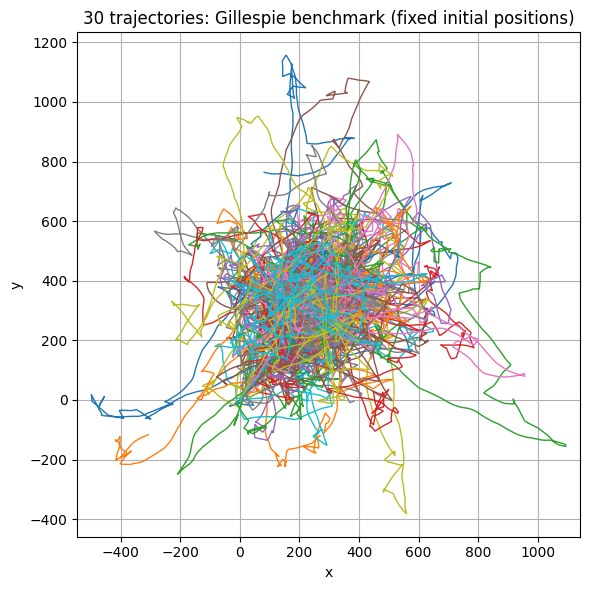

/tmp/ipykernel_10743/2960843255.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sum_gil = df_gill.groupby('run_id').apply(


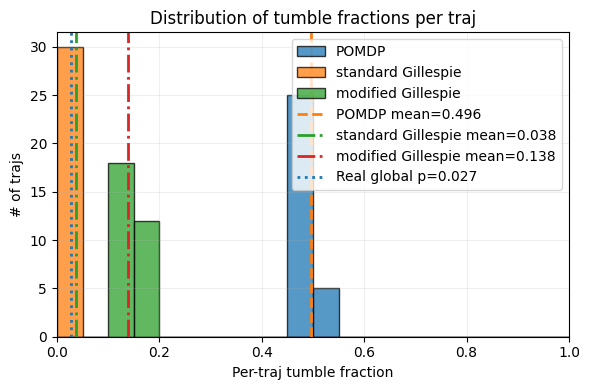

/tmp/ipykernel_10743/2448086154.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('run_id', as_index=False, group_keys=False).apply(_diff_vel)
/tmp/ipykernel_10743/2448086154.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('run_id', as_index=False, group_keys=False).apply(_diff_vel)


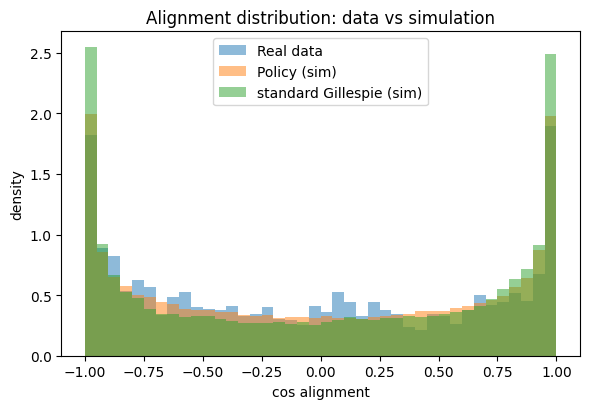

n_data              1.200000e+05
n_sim               1.199700e+05
KS_D                3.874642e-02
KS_p                1.082486e-78
W1                  4.412345e-02
JS                  3.222021e-03
hist_L1             1.406967e-01
E_cos_data         -3.364199e-03
E_cos_sim           1.689299e-02
P(cos>0.8)_data     2.029000e-01
P(cos>0.8)_sim      2.375511e-01
P(cos<-0.8)_data    2.038833e-01
P(cos<-0.8)_sim     2.331249e-01
dtype: float64

CIs (bootstrap 95%):
KS_D   in [0.035, 0.042]
W1     in [0.041, 0.047]
JS     in [0.003, 0.004]
hist_L1 in [0.134, 0.149]


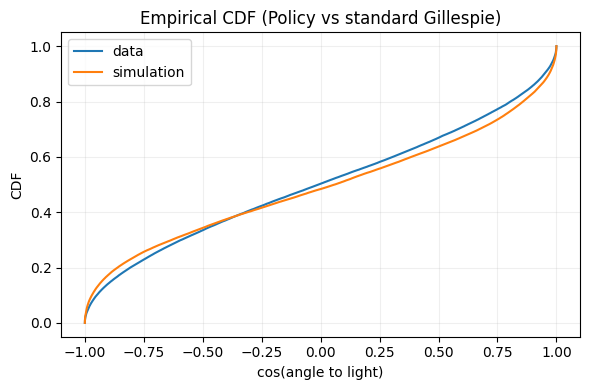

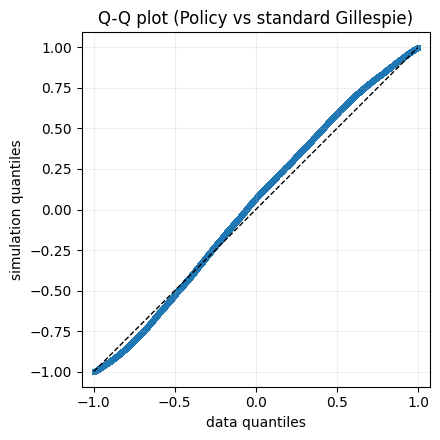

In [11]:
def simulate_gillespie(env, kin, x0, total_time=100., dt_grid=0.125,
                       rt_min_max=(0.1,1.0), gamma=1.0,
                       turn_noise_std=0.05, seed=0):
    rng = np.random.default_rng(seed)
    mu = np.asarray(env.src["mu"], float)
    c_run = float(kin["c_run"])
    x = np.array(x0, float)
    heading = _normalize(mu - x)
    t = 0.0
    t_next_out = dt_grid
    event_flag = 0

    def lam_rt(x, heading):
        align = (_alignment(x, heading, mu) + 1.0) * 0.5
        lam_min, lam_max = rt_min_max
        return lam_min + (lam_max - lam_min) * ((1.0 - align) ** gamma)

    lam = lam_rt(x, heading)
    t_next_event = t + rng.exponential(1.0 / max(lam, 1e-8))

    rows = []
    while t < total_time:
        t_end = min(t_next_out, t_next_event, total_time)
        h = t_end - t

        ang = rng.normal(0.0, turn_noise_std)
        R = np.array([[np.cos(ang), -np.sin(ang)],
                      [np.sin(ang),  np.cos(ang)]])
        heading = _normalize(R @ heading)
        x = x + h * (c_run * heading)
        t += h

        action = 0
        if abs(t - t_next_event) < 1e-12:
            phi = rng.uniform(0, 2*np.pi)
            heading = np.array([np.cos(phi), np.sin(phi)], float)
            lam = lam_rt(x, heading)
            t_next_event = t + rng.exponential(1.0 / max(lam, 1e-8))
            action = 1 - action
            event_flag = 1

        if abs(t - t_next_out) < 1e-12 or (t == total_time and t < t_next_out):
            rows.append(dict(
                t=t, dt=h, x=x[0], y=x[1],
                action=int(action),
                event=int(event_flag),
                align=_alignment(x, heading, mu)
            ))
            event_flag = 0
            t_next_out += dt_grid

    return pd.DataFrame(rows)

steps = 4000
dt_grid = dt_policy
total_time = steps * dt_grid

gill_trajs = []
for i in range(N):
    dfi_g = simulate_gillespie(
        env_new, kin_sim, x0=np.array([0, 0], dtype=float),
        total_time=total_time, dt_grid=dt_grid, seed=1000 + i
    )
    dfi_g.insert(0, 'run_id', i)
    gill_trajs.append(dfi_g)

df_gill = pd.concat(gill_trajs, ignore_index=True)
df_gill.to_csv(TRAJ_DIR / "trajs_gillespie.csv", index=False)

plt.figure(figsize=(6, 6))
for i in range(N):
    g_dfi = df_gill[df_gill.run_id == i]
    plt.plot(g_dfi.x.values, g_dfi.y.values, linewidth=1.0)
plt.scatter([light_xy[0]], [light_xy[1]])
plt.title("30 trajectories: Gillespie benchmark (fixed initial positions)")
plt.xlabel("x"); plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_trajectories_gillespie.png", dpi=160)
plt.show()

sum_gil = df_gill.groupby('run_id').apply(
    lambda g: pd.Series(dict(
        method='gillespie',
        step_ratio=float((g['event'] == 1).mean()),
        total=len(g)
    ))
).reset_index()

vals_p = sum_pol['step_ratio'].dropna().to_numpy()
vals_g = sum_gil["step_ratio"].dropna().to_numpy()
vals_gm = sum_gil_m["step_ratio"].dropna().to_numpy()

bins = np.linspace(0, 1, 21)
p_sim = vals_p.mean()
p_g = vals_g.mean()
p_gm = vals_gm.mean()

plt.figure(figsize=(6, 4))
plt.hist(vals_p, bins=bins, alpha=0.75, edgecolor="k", label="POMDP")
plt.hist(vals_g, bins=bins, alpha=0.75, edgecolor="k", label="standard Gillespie")
plt.hist(vals_gm, bins=bins, alpha=0.75, edgecolor="k", label="modified Gillespie")
plt.axvline(p_sim, color="C1", ls="--", lw=2, label=f"POMDP mean={p_sim:.3f}")
plt.axvline(p_g, color="C2", ls="-.", lw=2, label=f"standard Gillespie mean={p_g:.3f}")
plt.axvline(p_gm, color="C3", ls="-.", lw=2, label=f"modified Gillespie mean={p_gm:.3f}")
plt.axvline(p_real, color="C0", ls=":", lw=2, label=f"Real global p={p_real:.3f}")
plt.xlabel("Per-traj tumble fraction")
plt.ylabel("# of trajs")
plt.title("Distribution of tumble fractions per traj")
plt.legend()
plt.xlim(0, 1)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_tumble_ratio_threeway.png", dpi=160)
plt.show()

cos_policy = alignment_from_df(df_policy, mu)
cos_gill = alignment_from_df(df_gill, mu)

plt.figure(figsize=(6, 4.2))
plt.hist(data_cos, bins=40, density=True, alpha=0.5, label='Real data')
plt.hist(cos_policy, bins=40, density=True, alpha=0.5, label='Policy (sim)')
plt.hist(cos_gill, bins=40, density=True, alpha=0.5, label='standard Gillespie (sim)')
plt.xlabel('cos alignment')
plt.ylabel('density')
plt.title('Alignment distribution: data vs simulation')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_alignment_hist_policy_vs_standard_gillespie.png", dpi=160)
plt.show()

res_std = summarize_alignment(cos_gill, cos_policy, bins=40)
ks_ci_std = bootstrap_ci(lambda a, b: ks_2samp(a, b).statistic, cos_gill, cos_policy)
w1_ci_std = bootstrap_ci(lambda a, b: wasserstein_distance(a, b), cos_gill, cos_policy)
js_ci_std = bootstrap_ci(lambda a, b: js_divergence(a, b, bins=40), cos_gill, cos_policy)
l1_ci_std = bootstrap_ci(lambda a, b: hist_L1(a, b, bins=40), cos_gill, cos_policy)

print(pd.Series(res_std))
print("\nCIs (bootstrap 95%):")
print(f"KS_D   in [{ks_ci_std[0]:.3f}, {ks_ci_std[1]:.3f}]")
print(f"W1     in [{w1_ci_std[0]:.3f}, {w1_ci_std[1]:.3f}]")
print(f"JS     in [{js_ci_std[0]:.3f}, {js_ci_std[1]:.3f}]")
print(f"hist_L1 in [{l1_ci_std[0]:.3f}, {l1_ci_std[1]:.3f}]")

plot_cdf_compare(cos_policy, cos_gill,
                 title="Empirical CDF (Policy vs standard Gillespie)",
                 savepath=FIG_DIR / "fig_cdf_policy_vs_standard_gillespie.png")
plot_qq_compare(cos_policy, cos_gill,
                title="Q-Q plot (Policy vs standard Gillespie)",
                savepath=FIG_DIR / "fig_qq_policy_vs_standard_gillespie.png")

## Tau calibration

In [12]:
import numpy as np, torch

@torch.no_grad()
def _sim_tumble_ratio_once(env, r_star, tau, kin, steps, dt, seed, x0=None, random=False):
    """Run a single simulation and return its tumble ratio (counted per step)."""
    policy_fn = policy_from_reward(r_star, env.TT, env.ZZ, tau=float(tau), curiosity=0.0)
    traj, acts, bels, vlist = simulate_pomdp(
        env, policy_fn, kin, steps=steps, dt=dt, seed=seed, x0=x0, random=random
    )
    return float((acts == 1).mean()) if acts.size > 0 else np.nan

@torch.no_grad()
def eval_tau_by_sim(env, r_star, tau, kin, steps=800, dt=0.125,
                    n_runs=8, base_seed=0, random_init=False, x0=None):
    """Given tau, run multiple simulations and return the mean and standard deviation."""
    ratios = []
    for k in range(n_runs):
        seed = int(base_seed + k)
        r = _sim_tumble_ratio_once(
            env, r_star, tau, kin, steps=steps, dt=dt,
            seed=seed, x0=x0, random=random_init
        )
        ratios.append(r)
    ratios = np.asarray(ratios, float)
    return float(np.nanmean(ratios)), float(np.nanstd(ratios))

@torch.no_grad()
def calibrate_tau_by_sim(env, r_star, kin,
                         target_ratio,
                         steps=800, dt=0.125,
                         coarse_range=(1e-3, 2.0), coarse_points=25, coarse_log=True,
                         refine_iters=3, grid_each=21, span0=5.0, shrink=3.0,
                         n_runs=8, base_seed=0, random_init=False, x0=None,
                         verbose=True):
    lo, hi = map(float, coarse_range)
    if coarse_log:
        taus0 = np.exp(np.linspace(np.log(lo), np.log(hi), int(coarse_points)))
    else:
        taus0 = np.linspace(lo, hi, int(coarse_points))
    table = []

    def _push_result(tau, mean_ratio, std_ratio):
        table.append(dict(
            tau=float(tau),
            ratio=float(mean_ratio),
            ratio_std=float(std_ratio),
            err=float(abs(mean_ratio - target_ratio))
        ))

    if verbose:
        print(f"[τ-calib] target_ratio = {target_ratio:.4f}")
        print(f"[coarse] range=({lo:.3g},{hi:.3g}) points={len(taus0)} log={coarse_log}")

    for tau in taus0:
        m, s = eval_tau_by_sim(
            env, r_star, tau, kin, steps=steps, dt=dt,
            n_runs=n_runs, base_seed=base_seed,
            random_init=random_init, x0=x0
        )
        _push_result(tau, m, s)
        if verbose:
            print(f"  tau={tau:8.5f}  ratio={m:.4f}±{s:.4f}  |err|={abs(m-target_ratio):.4f}")

    table.sort(key=lambda d: d["err"])
    tau_best = table[0]["tau"]
    if verbose:
        print(f"[coarse] best tau={tau_best:.6f}  ratio={table[0]['ratio']:.4f}  |err|={table[0]['err']:.4f}")

    at_lower = np.isclose(tau_best, np.min(taus0))
    at_upper = np.isclose(tau_best, np.max(taus0))
    if at_lower or at_upper:
        if verbose:
            side = "LOWER" if at_lower else "UPPER"
            print(f"[expand] best at {side} boundary, expanding search range...")
        if at_lower:
            lo2, hi2 = tau_best / 10.0, tau_best * span0
        else:
            lo2, hi2 = tau_best / span0, tau_best * 10.0
        taus_exp = np.exp(np.linspace(np.log(max(lo2, 1e-6)), np.log(hi2), grid_each))
        for tau in taus_exp:
            m, s = eval_tau_by_sim(
                env, r_star, tau, kin, steps=steps, dt=dt,
                n_runs=n_runs, base_seed=base_seed + 999,
                random_init=random_init, x0=x0
            )
            _push_result(tau, m, s)
            if verbose:
                print(f"  tau={tau:8.5f}  ratio={m:.4f}±{s:.4f}  |err|={abs(m-target_ratio):.4f}")
        table.sort(key=lambda d: d["err"])
        tau_best = table[0]["tau"]
        if verbose:
            print(f"[expand] best tau={tau_best:.6f}  ratio={table[0]['ratio']:.4f}  |err|={table[0]['err']:.4f}")

    span = float(span0)
    for it in range(refine_iters):
        lo_i = max(1e-6, tau_best / span)
        hi_i = tau_best * span
        taus_i = np.exp(np.linspace(np.log(lo_i), np.log(hi_i), grid_each))
        if verbose:
            print(f"[refine {it+1}/{refine_iters}] around {tau_best:.6f}, "
                  f"log-range=({lo_i:.6f},{hi_i:.6f}), grid={grid_each}")
        for tau in taus_i:
            m, s = eval_tau_by_sim(
                env, r_star, tau, kin, steps=steps, dt=dt,
                n_runs=n_runs, base_seed=base_seed + 1000 * (it + 1),
                random_init=random_init, x0=x0
            )
            _push_result(tau, m, s)
            if verbose:
                print(f"  tau={tau:8.6f}  ratio={m:.4f}±{s:.4f}  |err|={abs(m-target_ratio):.4f}")
        table.sort(key=lambda d: d["err"])
        tau_best = table[0]["tau"]
        if verbose:
            print(f"[refine {it+1}] best tau={tau_best:.6f}  ratio={table[0]['ratio']:.4f}  |err|={table[0]['err']:.4f}")
        span = max(1.5, span / float(shrink))

    return tau_best, table

Tau search target_ratio = 0.02727474123217852
[τ-calib] target_ratio = 0.0273
[coarse] range=(0.001,2) points=25 log=True
  tau= 0.00100  ratio=0.0089±0.0052  |err|=0.0184
  tau= 0.00137  ratio=0.0089±0.0052  |err|=0.0184
  tau= 0.00188  ratio=0.0088±0.0054  |err|=0.0185
  tau= 0.00259  ratio=0.0088±0.0054  |err|=0.0185
  tau= 0.00355  ratio=0.0088±0.0054  |err|=0.0185
  tau= 0.00487  ratio=0.0083±0.0043  |err|=0.0190
  tau= 0.00669  ratio=0.0173±0.0047  |err|=0.0099
  tau= 0.00918  ratio=0.0372±0.0081  |err|=0.0099
  tau= 0.01260  ratio=0.0705±0.0108  |err|=0.0432
  tau= 0.01729  ratio=0.1334±0.0158  |err|=0.1062
  tau= 0.02374  ratio=0.2069±0.0197  |err|=0.1796
  tau= 0.03258  ratio=0.3478±0.2152  |err|=0.3205
  tau= 0.04472  ratio=0.3227±0.0298  |err|=0.2954
  tau= 0.06138  ratio=0.4139±0.1326  |err|=0.3866
  tau= 0.08426  ratio=0.4363±0.0931  |err|=0.4090
  tau= 0.11565  ratio=0.4570±0.0919  |err|=0.4298
  tau= 0.15874  ratio=0.4331±0.0151  |err|=0.4059
  tau= 0.21789  ratio=0.4470

,tau,ratio,ratio_std,err
0,0.001000,0.008906,0.005245,0.018368
1,0.001373,0.008906,0.005245,0.018368
2,0.001884,0.008750,0.005413,0.018525
3,0.002586,0.008750,0.005413,0.018525
4,0.003060,0.010625,0.008524,0.016650


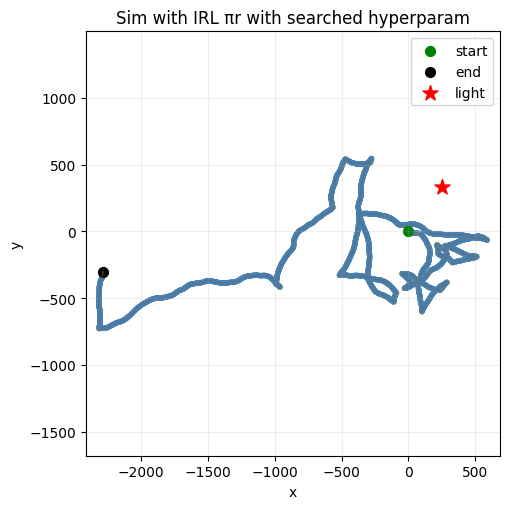

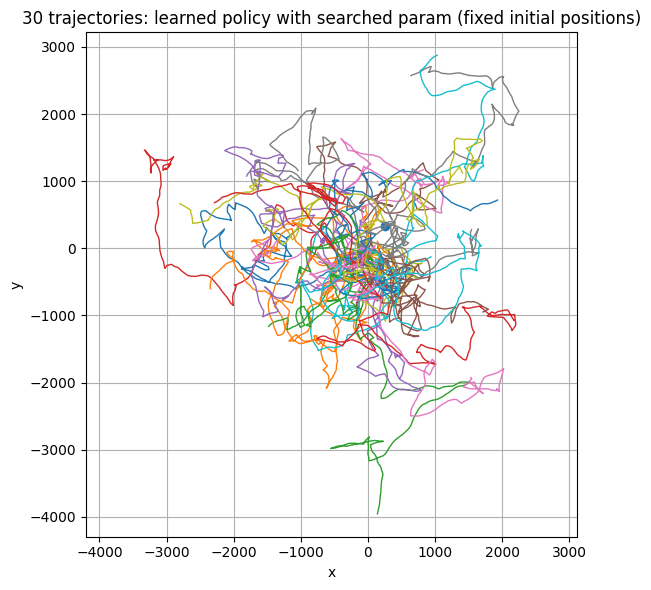

/tmp/ipykernel_10743/309788619.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sum_pol_b = df_policy_b.groupby('run_id').apply(


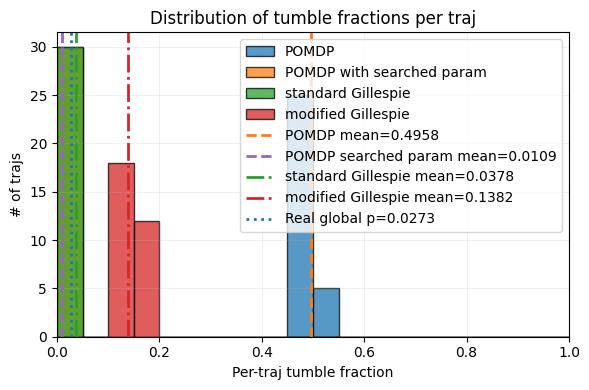

/tmp/ipykernel_10743/2448086154.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('run_id', as_index=False, group_keys=False).apply(_diff_vel)


,KS,KS_p,W1,JS,hist_L1
pair,,,,,
Policy vs Gillespie,0.1122,0.0000,0.1593,0.0072,0.2232
Real vs Gillespie,0.0650,0.0000,0.0638,0.0062,0.1894
Real vs Policy,0.0797,0.0000,0.1006,0.0075,0.1958



95% bootstrap CI:
- Real vs Policy: KS[0.063,0.100]  W1[0.075,0.126]  JS[0.0070,0.0118]  L1[0.190,0.253]
- Real vs Gillespie: KS[0.050,0.084]  W1[0.045,0.087]  JS[0.0058,0.0102]  L1[0.174,0.241]
- Policy vs Gillespie: KS[0.108,0.117]  W1[0.154,0.165]  JS[0.0068,0.0078]  L1[0.215,0.232]


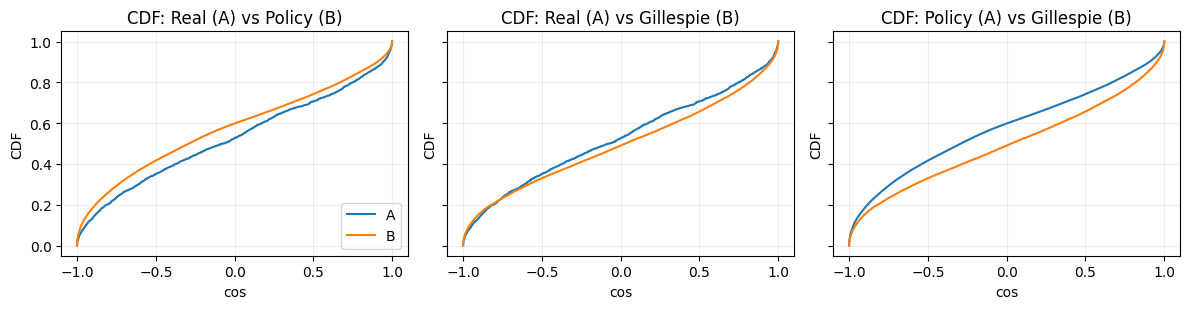

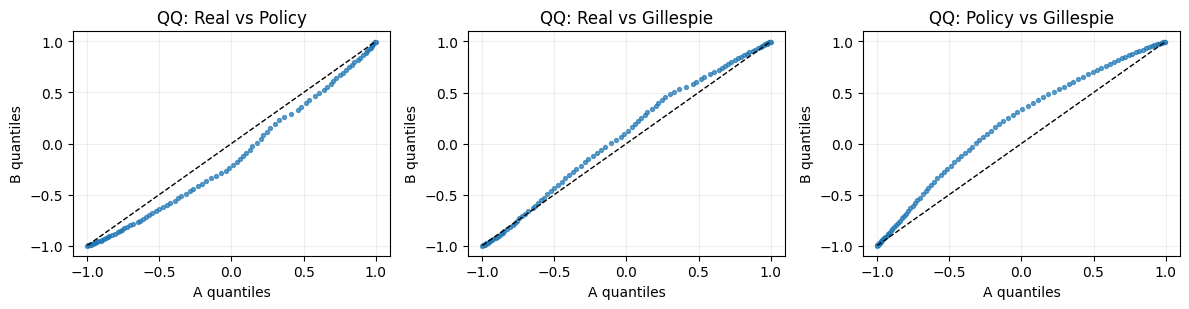

In [13]:
# Prefer the frozen benchmark target exported by 02
target_ratio = p_real
print("Tau search target_ratio =", target_ratio)



tau_best, table = calibrate_tau_by_sim(
    env=env_new, r_star=r_star, kin=kin_sim,
    target_ratio=target_ratio,
    steps=800, dt=0.125,
    coarse_range=(1e-3, 2.0), coarse_points=25, coarse_log=True,
    refine_iters=3, grid_each=21, span0=3.0, shrink=3.0,
    n_runs=8, base_seed=0, random_init=False, x0=None,
    verbose=True
)

print("\n==> tau_best =", tau_best)

df_tau = pd.DataFrame(table).sort_values("tau").reset_index(drop=True)
display(df_tau.head())
df_tau.to_csv(TAB_DIR / "tau_search_table.csv", index=False)

pi_r_b = policy_from_reward(r_star, env_new.TT, env_new.ZZ, tau=tau_best, curiosity=0.0)
traj_b, acts_b, bels_b, vlist_b = simulate_pomdp(
    env_new, pi_r_b, kin_sim, steps=4000, dt=dt_policy, seed=0
)
plot_trajectory(
    traj_b, acts_b, src_mu=env_new.src["mu"],
    title="Sim with IRL πr with searched hyperparam",
    savepath=FIG_DIR / "fig_one_trajectory_policy_searched_param.png"
)

N = 30
policy_trajs_b = []
for i in range(N):
    traj_b, acts_b, bels_b, vlist_b = simulate_pomdp(
        env_new, pi_r_b, kin_sim, random=False, steps=4000, dt=dt_policy, seed=1000 + i
    )
    run_id_b = np.full(len(traj_b), i, int)
    step_id_b = np.arange(len(traj_b))
    acts_b = [0] + acts_b.tolist()

    df_one_b = pd.DataFrame(dict(
        run_id=run_id_b,
        step=step_id_b,
        x=traj_b[:, 0],
        y=traj_b[:, 1],
        action=acts_b,
        dt=dt_policy
    ))
    policy_trajs_b.append(df_one_b)

df_policy_b = pd.concat(policy_trajs_b, ignore_index=True)
df_policy_b.to_csv(TRAJ_DIR / "trajs_policy_searched_param.csv", index=False)

plt.figure(figsize=(6, 6))
for i in range(N):
    dfi_b = df_policy_b[df_policy_b.run_id == i]
    plt.plot(dfi_b.x.values, dfi_b.y.values, linewidth=1.0)
plt.scatter([light_xy[0]], [light_xy[1]])
plt.title("30 trajectories: learned policy with searched param (fixed initial positions)")
plt.xlabel("x"); plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_trajectories_policy_searched_param.png", dpi=160)
plt.show()

sum_pol_b = df_policy_b.groupby('run_id').apply(
    lambda g: pd.Series(dict(
        method='policy with searched param',
        step_ratio=float((g['action'] == 1).mean()),
        time_ratio=float((g['action'] * g['dt']).sum() / g['dt'].sum())
    ))
).reset_index()

vals_p_b = sum_pol_b['step_ratio'].dropna().to_numpy()
bins = np.linspace(0, 1, 21)
p_sim_b = vals_p_b.mean()

plt.figure(figsize=(6, 4))
plt.hist(vals_p, bins=bins, alpha=0.75, edgecolor="k", label="POMDP")
plt.hist(vals_p_b, bins=bins, alpha=0.75, edgecolor="k", label="POMDP with searched param")
plt.hist(vals_g, bins=bins, alpha=0.75, edgecolor="k", label="standard Gillespie")
plt.hist(vals_gm, bins=bins, alpha=0.75, edgecolor="k", label="modified Gillespie")
plt.axvline(p_sim, color="C1", ls="--", lw=2, label=f"POMDP mean={p_sim:.4f}")
plt.axvline(p_sim_b, color="C4", ls="--", lw=2, label=f"POMDP searched param mean={p_sim_b:.4f}")
plt.axvline(p_g, color="C2", ls="-.", lw=2, label=f"standard Gillespie mean={p_g:.4f}")
plt.axvline(p_gm, color="C3", ls="-.", lw=2, label=f"modified Gillespie mean={p_gm:.4f}")
plt.axvline(p_real, color="C0", ls=":", lw=2, label=f"Real global p={p_real:.4f}")
plt.xlabel("Per-traj tumble fraction")
plt.ylabel("# of trajs")
plt.title("Distribution of tumble fractions per traj")
plt.legend()
plt.xlim(0, 1)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_tumble_ratio_with_tau_calibration.png", dpi=160)
plt.show()

data_cos_b = alignment_from_df(df_policy_b, mu)
df_metrics_b, cis_b = summarize_(data_cos, data_cos_b, cos_gill_m, bins=40, B=800)
display(df_metrics_b.style.format("{:.4f}"))

print("\n95% bootstrap CI:")
for pair, d in cis_b.items():
    print(
        f"- {pair}: "
        f"KS[{d['KS'][0]:.3f},{d['KS'][1]:.3f}]  "
        f"W1[{d['W1'][0]:.3f},{d['W1'][1]:.3f}]  "
        f"JS[{d['JS'][0]:.4f},{d['JS'][1]:.4f}]  "
        f"L1[{d['hist_L1'][0]:.3f},{d['hist_L1'][1]:.3f}]"
    )

plot_cdf_three(data_cos, data_cos_b, cos_gill_m,
               savepath=FIG_DIR / "fig_cdf_threeway_tau_calibrated.png")
plot_qq_three(data_cos, data_cos_b, cos_gill_m,
              savepath=FIG_DIR / "fig_qq_threeway_tau_calibrated.png")

df_metrics_b.to_csv(TAB_DIR / "benchmark_summary_tau_calibrated.csv")